In [ ]:
# pip install getdist matplotlib
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots

# ---------------- Planck roots (wCDM) ----------------
planck_base_dir   = "/home/geng/Codes/sgl_cosmo/jax01/data"
planck_base_label = "base_w"  # 如需改成别的（例如 base_w_wa），改这里

root_nobao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE"
#     f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE"
)
root_bao = os.path.join(
    planck_base_dir, planck_base_label,
    "plikHM_TTTEEE_lowl_lowE_BAO"
    # f"{planck_base_label}_plikHM_TTTEEE_lowl_lowE_BAO"
)
# 若需 CMB lensing，把上面两个 root 改成 *_post_lensing 版本

# ---------------- 本地链设置 ----------------
base_dir = "/home/astrodust/SG/sgl_cosmo/GLS_cosmo01"
# local_pairs = [("linear", "Tri"), ("linear", "0.22")]  
local_pairs = [("linear", "0.22")]  
local_col_order = ('omegam', 'w')  # 若本地链顺序为 (w, Ωm) 则改为 ('w','omegam')

# ---------------- 工具函数 ----------------
def ensure_omegam_and_w(samples):
    """确保 Planck 样本里有 omegam 与 w（若 w0 存在则派生 w），并设置合适标签（GetDist 标签不要加 $）"""
    names = {p.name for p in samples.getParamNames().names}
    P = samples.getParams()

    # w
    if 'w' not in names:
        if hasattr(P, 'w0'):
            samples.addDerived(P.w0, name='w', label='w')
        elif hasattr(P, 'w'):
            pass
        else:
            raise RuntimeError("此 Planck 链未包含 w/w0；请改用 base_w 类链或相应 root。")

    # Ωm
    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2)/P.h**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2,
                                   name='omegam', label=r'\Omega_{\rm m}')
        elif hasattr(P, 'omega_m'):
            samples.addDerived(P.omega_m, name='omegam', label=r'\Omega_{\rm m}')

    try: samples.setLabel('omegam', r'\Omega_{\rm m}')
    except: pass
    try: samples.setLabel('w', 'w')
    except: pass
    return samples

def numpy_to_mcsamples(arr, burnin_frac=0.30, order=('omegam','w')):
    """
    将本地 numpy 链转为 MCSamples。
    order 指定列的物理含义与输出顺序（'omegam'/'w' 的排列）。
    """
    # 展平并去掉 burn-in
    if arr.ndim == 3:
        nwalk, nstep, ndim = arr.shape
        start = int(burnin_frac * nstep)
        flat = arr[:, start:, :].reshape(-1, ndim)
    else:
        flat = arr
        ndim = flat.shape[-1]

    if set(order) != {'omegam','w'} or len(order) != 2:
        raise ValueError("order 必须是 ('omegam','w') 或 ('w','omegam')")

    # 如果实际列顺序与 order 不符，这里交换
    # 假设原始列为 [Ωm, w]；若 order=('w','omegam') 则交换：
    if order == ('w', 'omegam'):
        flat = flat[:, [1, 0]]

    # 用标准内部名字 + 无 $ 的标签
    names  = ['omegam', 'w']
    labels = [r'\Omega_{\rm m}', 'w']
    mcs = MCSamples(samples=flat, names=names, labels=labels)
    # 可选：再设置 chain 级别的显示名（用于图例）；由外部赋值更灵活
    return mcs

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    """汇总多组样本求统一坐标轴范围（分位数+边距）"""
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad*w, hi + pad*w

# ======= 放在你的“画图前”工具区 =======
from scipy.stats import gaussian_kde

def extract_2col_from_mcs(mcs, xname='omegam', yname='w'):
    """从 MCSamples 中取两个参数组成 (N,2) 数组"""
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde(base_mcs, ref_pts, label, bw='scott'):
    """
    用 ref_pts(N,2) 的 KDE 在 base_mcs 的 (Ωm,w) 点上评估密度，作为附加权重，得到“联合后验”。
    假设两边对 (Ωm,w) 的先验一致或近似均匀；若先验不同，需要在这里做 prior 校正。
    """
    base_pts = extract_2col_from_mcs(base_mcs, 'omegam', 'w')     # (N,2)
    w_base   = base_mcs.weights if base_mcs.weights is not None else np.ones(base_pts.shape[0])

    kde = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = kde(base_pts.T)                                        # p(theta | SL+SN)
    # 数值稳定化（只差一个归一化常数，不影响后验形状）
    dens = np.clip(dens, 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(
        samples=base_pts,
        names=['omegam','w'],
        labels=[r'\Omega_{\rm m}','w'],
        weights=w_joint
    )
    joint.label = label
    return joint


# ---------------- 加载 Planck 链 ----------------
planck_nobao = loadMCSamples(root_nobao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_nobao = ensure_omegam_and_w(planck_nobao)

planck_bao = loadMCSamples(root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_omegam_and_w(planck_bao)

# ---------------- 加载本地链（linear + Tri / 0.22） ----------------
local_mcs = []
for evo, prior in local_pairs:
    f = os.path.join(base_dir, "Output", f"{evo}-{prior}", f"mcmc_cosmop2D-{evo}-{prior}.npy")
    if not os.path.isfile(f):
        raise FileNotFoundError(f"找不到本地链文件: {f}")
    arr = np.load(f)
    mcs = numpy_to_mcsamples(arr, burnin_frac=0.30, order=local_col_order)
    mcs.label = f"{evo} + {prior}"
    local_mcs.append(mcs)


# ======= 重要性重加权：Planck+BAO × (SL+SN) 得到“联合后验” =======
# --- 提取 SL+SN 的样本点 (Ωm,w) 作为 KDE 参考 ---
L = local_mcs[0]                              # 你现在 local_pairs 里只有一条：Strong Lensing + SN Ia
local_pts = extract_2col_from_mcs(L, 'omegam', 'w')

# --- 1) Joint: Planck (noBAO) × (SL+SN) ---
joint_planck = make_joint_by_kde(
    planck_nobao, local_pts,
    label=r'Joint: Planck × (SL+SN)',
    bw='scott'   # 可试 'silverman' 或数值带宽
)

# --- 2) Joint: Planck+BAO × (SL+SN) ---
joint_planck_bao = make_joint_by_kde(
    planck_bao, local_pts,
    label=r'Joint: Planck+BAO × (SL+SN)',
    bw='scott'
)


# （可选）等效重采样，得到等权样本用于导出/再处理：
# joint_eq = joint.resample_chain(nsamp=planck_pts.shape[0], seed=1234)


# ---------------- 画 Ωm – w：先画外轮廓，再叠加联合后验的填充 ----------------
# all_samples = [planck_nobao, planck_bao] + local_mcs + [joint_planck, joint_planck_bao]
all_samples = [planck_nobao, planck_bao] + local_mcs + [joint_planck]
legend_labels = [
    r'Planck TTTEEE+lowE',
    r'Planck TTTEEE+lowE+BAO',
    r'Strong Lensing + SN Ia',
    r'Joint: Planck × (SL+SN)',
    # r'Joint: Planck+BAO × (SL+SN)',
]

colors = ['#1f77b4', '#d62728', '#2ca02c', 'orange', '#8c564b']  # 蓝/红/绿/紫/棕
line_args = [
    {'ls': '-',  'lw': 1.6},   # Planck noBAO 轮廓
    {'ls': '--', 'lw': 1.6},   # Planck+BAO 轮廓
    {'ls': '-',  'lw': 1.6},   # SL+SN 轮廓
    {'ls': '--',  'lw': 1.6},   # 联合(Planck) 的“线框”用于图例
    # {'ls': '-',  'lw': 1.6},   # 联合(Planck+BAO) 的“线框”用于图例
]

g = plots.get_subplot_plotter(width_inch=6.8)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

# 先画五条外轮廓（用于统一 legend 和坐标范围）
g.plot_2d(
    all_samples,
    ['omegam', 'w'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=legend_labels,
)

# # 再把两条“联合”以填充形式叠加，视觉更清晰（不再创建 legend 代理）
g.plot_2d(joint_planck,      ['omegam','w'], filled=True, colors=[colors[3]], add_legend_proxy=False, alpha=0.3)
# g.plot_2d(joint_planck_bao,  ['omegam','w'], filled=True, colors=[colors[4]], add_legend_proxy=False, alpha=0.3)

# 坐标范围（自动聚合所有样本的分位数）
ax = g.subplots[0, 0]
xlim = auto_limits_multi(all_samples, 'omegam') or (0.0, 1.05)
ylim = auto_limits_multi(all_samples, 'w')      or (-2.5, -0.5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$')
ax.set_ylabel(r'$w$')

g.add_legend(legend_labels,
             legend_loc='lower left', colored_text=False)

# 参考线
ax.axvline(0.3,  color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)
ax.axhline(-1.0, color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)

out = "combined_omegam_w_planck_vs_local_with_joint.png"
g.export(out)
# print(f"Saved: {out}")


Removed no burn in
Saved: /home/geng/Codes/sgl_cosmo/jax01/joint_plots/omegam_w_local_sgl140a.png


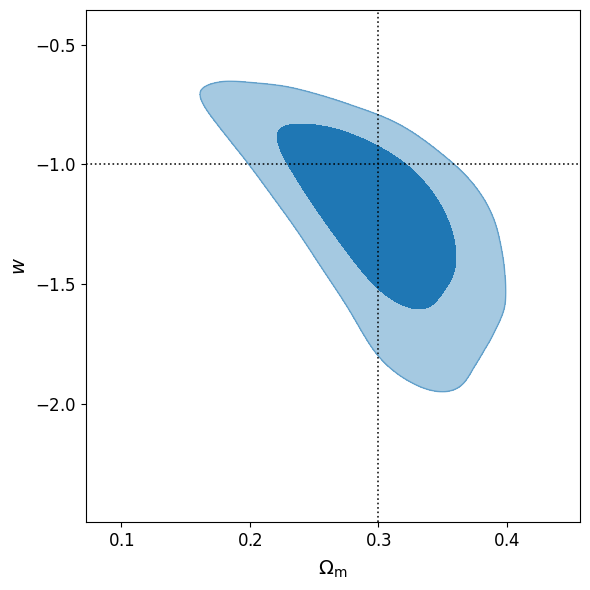

In [1]:
# Local NPZ chain: sgl140a_wcdm_main (Omega_m - w)
import os
import numpy as np
from getdist.mcsamples import MCSamples
from getdist import plots

npz_path = '/home/geng/Codes/sgl_cosmo/jax01/output/posterior_minimal_chunks_sgl140a_wcdm_main.npz'
if not os.path.exists(npz_path):
    raise FileNotFoundError(f'Missing npz: {npz_path}')

d = np.load(npz_path)
required = ['Om', 'w']
missing = [k for k in required if k not in d]
if missing:
    raise KeyError(f'NPZ missing keys: {missing}')

# Stack to (N,2): [Omega_m, w]
samples = np.column_stack([d['Om'], d['w']])

mcs_local = MCSamples(
    samples=samples,
    names=['omegam', 'w'],
    labels=[r'\Omega_{\rm m}', 'w'],
)
mcs_local.label = 'sgl140a wCDM (local NPZ)'

g = plots.get_subplot_plotter(width_inch=6.0)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

g.plot_2d(
    mcs_local,
    ['omegam', 'w'],
    filled=True,
    colors=['#1f77b4'],
    legend_labels=['sgl140a wCDM (local NPZ)'],
)

ax = g.subplots[0, 0]
ax.axvline(0.3, color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)
ax.axhline(-1.0, color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$')
ax.set_ylabel(r'$w$')

out = '/home/geng/Codes/sgl_cosmo/jax01/joint_plots/omegam_w_local_sgl140a.png'
g.export(out)
print(f'Saved: {out}')


Removed no burn in
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_1.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_2.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_3.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_4.txt
Removed no burn in
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_l

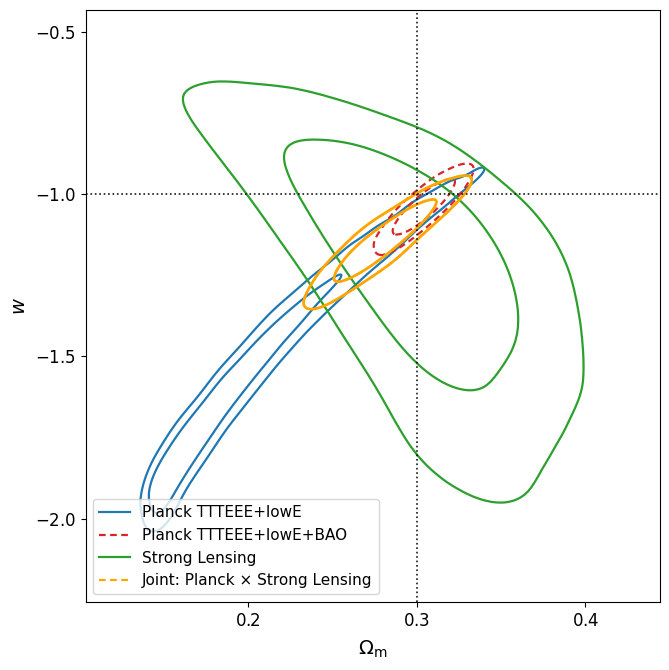

In [1]:
# Local NPZ + Planck overlays (same style as cell 0)
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ---------------- Planck roots (wCDM) ----------------
planck_base_label = "base_w"
_planck_dir_candidates = [
    "/home/geng/Codes/sgl_cosmo/jax01/data/planck_data",
    "/home/geng/Codes/sgl_cosmo/jax01/data",
]

def _resolve_planck_root(base_label, chain_name):
    tried = []
    for d in _planck_dir_candidates:
        # 1) direct root style: .../base_w/plikHM_... (rare)
        root1 = os.path.join(d, base_label, chain_name)
        tried.append(root1)
        if os.path.exists(root1 + '_1.txt') or os.path.exists(root1 + '.paramnames') or os.path.exists(root1 + '.ranges'):
            return root1

        # 2) common Planck layout in your tree:
        #    .../base_w/plikHM_.../base_w_plikHM_...
        root2 = os.path.join(d, base_label, chain_name, f"{base_label}_{chain_name}")
        tried.append(root2)
        if os.path.exists(root2 + '_1.txt') or os.path.exists(root2 + '.paramnames') or os.path.exists(root2 + '.ranges'):
            return root2

    raise FileNotFoundError(
        "Planck chain root not found. Tried:\n" + "\n".join(tried) +
        "\nPlease check your chain folder layout."
    )

root_nobao = _resolve_planck_root(planck_base_label, "plikHM_TTTEEE_lowl_lowE")
root_bao = _resolve_planck_root(planck_base_label, "plikHM_TTTEEE_lowl_lowE_BAO")

# ---------------- Local NPZ chain ----------------
npz_path = '/home/geng/Codes/sgl_cosmo/jax01/output/posterior_minimal_chunks_sgl140a_wcdm_main.npz'
if not os.path.exists(npz_path):
    raise FileNotFoundError(f'Missing npz: {npz_path}')

d = np.load(npz_path)
required = ['Om', 'w']
missing = [k for k in required if k not in d]
if missing:
    raise KeyError(f'NPZ missing keys: {missing}')

local_samples = np.column_stack([d['Om'], d['w']])
local_mcs = MCSamples(
    samples=local_samples,
    names=['omegam', 'w'],
    labels=[r'\Omega_{\rm m}', 'w'],
)
local_mcs.label = 'Strong Lensing'


# ---------------- Utility functions (same method as first cell) ----------------
def ensure_omegam_and_w(samples):
    names = {p.name for p in samples.getParamNames().names}
    P = samples.getParams()

    if 'w' not in names:
        if hasattr(P, 'w0'):
            samples.addDerived(P.w0, name='w', label='w')
        else:
            raise RuntimeError('Planck chain has no w/w0')

    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2) / P.h**2, name='omegam', label=r'\Omega_{\rm m}')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2) / (P.H0/100.0)**2, name='omegam', label=r'\Omega_{\rm m}')
    try:
        samples.setLabel('omegam', r'\Omega_{\rm m}')
    except Exception:
        pass
    try:
        samples.setLabel('w', 'w')
    except Exception:
        pass
    return samples

def extract_2col_from_mcs(mcs, xname='omegam', yname='w'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde(base_mcs, ref_pts, label, bw='scott'):
    base_pts = extract_2col_from_mcs(base_mcs, 'omegam', 'w')
    w_base = base_mcs.weights if base_mcs.weights is not None else np.ones(base_pts.shape[0])

    kde = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = kde(base_pts.T)
    dens = np.clip(dens, 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(
        samples=base_pts,
        names=['omegam', 'w'],
        labels=[r'\Omega_{\rm m}', 'w'],
        weights=w_joint,
    )
    joint.label = label
    return joint

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad * w, hi + pad * w

# ---------------- Load Planck chains ----------------
planck_nobao = loadMCSamples(root_nobao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_nobao = ensure_omegam_and_w(planck_nobao)

planck_bao = loadMCSamples(root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_omegam_and_w(planck_bao)

# ---------------- Joint: Planck x local ----------------
local_pts = extract_2col_from_mcs(local_mcs, 'omegam', 'w')
joint_planck = make_joint_by_kde(
    planck_nobao,
    local_pts,
    label=r'Joint: Planck × Strong Lensing',
    bw='scott',
)

# ---------------- Plot (same overlay style) ----------------
all_samples = [planck_nobao, planck_bao, local_mcs, joint_planck]
legend_labels = [
    r'Planck TTTEEE+lowE',
    r'Planck TTTEEE+lowE+BAO',
    r'Strong Lensing',
    r'Joint: Planck × Strong Lensing',
]
colors = ['#1f77b4', '#d62728', '#2ca02c', 'orange']
line_args = [
    {'ls': '-',  'lw': 1.6},
    {'ls': '--', 'lw': 1.6},
    {'ls': '-',  'lw': 1.6},
    {'ls': '--', 'lw': 1.6},
]

g = plots.get_subplot_plotter(width_inch=6.8)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 12
g.settings.legend_fontsize = 11

g.plot_2d(
    all_samples,
    ['omegam', 'w'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=legend_labels,
)
g.plot_2d(joint_planck, ['omegam', 'w'], filled=False, colors=[colors[3]], add_legend_proxy=False, alpha=0.3)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(all_samples, 'omegam') or (0.0, 1.05)
ylim = auto_limits_multi(all_samples, 'w') or (-2.5, -0.5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$')
ax.set_ylabel(r'$w$')

ax.axvline(0.3,  color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)
ax.axhline(-1.0, color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)

g.add_legend(legend_labels, legend_loc='lower left', colored_text=False)

out = '/home/geng/Codes/sgl_cosmo/jax01/joint_plots/combined_omegam_w_planck_vs_local_with_joint.png'
g.export(out)
print(f'Saved: {out}')


In [4]:
# === (2) 一维统计量：mean/sigma、median/MAD、peak/q16/q84（含相对 peak 的不对称误差）===
import numpy as np
from scipy.stats import gaussian_kde

def _normalize_weights(w):
    if w is None: return None
    w = np.asarray(w, float)
    s = np.sum(w)
    if s <= 0 or not np.isfinite(s): return None
    return w / s

def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def _weighted_quantiles(x, qs, w=None):
    qs = np.atleast_1d(qs).astype(float)
    return np.array([_weighted_quantile(x, q, w) for q in qs])

def _weighted_median(x, w=None):
    return _weighted_quantile(x, 0.5, w)

def _weighted_mad(x, w=None, scale=1.4826):
    med = _weighted_median(x, w)
    return scale * _weighted_median(np.abs(x - med), w)

def _oned_peak(x, w=None, grids=2048):
    x = np.asarray(x, float)
    grid = np.linspace(np.min(x), np.max(x), grids)
    kde  = gaussian_kde(x, weights=w) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return grid[np.argmax(dens)]

def _weighted_mean_sigma(x, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.mean(x), np.std(x, ddof=0)
    wn = _normalize_weights(w)
    mu = np.sum(wn * x)
    sig = np.sqrt(np.sum(wn * (x - mu)**2))
    return mu, sig

def _get_param_array(mcs, name):
    P = mcs.getParams()
    return np.asarray(getattr(P, name), float)

def summarize_mcs_1dset(mcs, names=('omegam','w')):
    out = {}
    wts = None if mcs.weights is None else np.asarray(mcs.weights, float)
    for nm in names:
        arr = _get_param_array(mcs, nm)
        mean, sigma = _weighted_mean_sigma(arr, wts)
        med  = _weighted_median(arr, wts)
        mad  = _weighted_mad(arr, wts)
        pk   = _oned_peak(arr, wts)
        q16, q84 = _weighted_quantiles(arr, [0.16, 0.84], wts)
        out[nm] = dict(
            mean=mean, sigma=sigma,
            median=med, mad=mad,
            peak=pk, q16=q16, q84=q84,
            dmed_minus=med-q16, dmed_plus=q84-med
        )
    return out

def print_summary_1d(tag, summ, names=('omegam','w')):
    print(f"\n=== {tag} ===")
    for nm in names:
        s = summ[nm]
        peak_txt   = f"peak = {s['peak']:.6f} "
        median_txt = f"median = {s['median']:.6f} (q16={s['q16']:.6f}, q84={s['q84']:.6f};  Δ-={s['dmed_minus']:.6f}, Δ+={s['dmed_plus']:.6f}) (MAD={s['mad']:.6f})"
        mean_txt   = f"mean = {s['mean']:.6f}, sigma = {s['sigma']:.6f}"
        print(f"{nm:7s}: {peak_txt} | {median_txt} | {mean_txt}")

# ---- 按 5 组输出（需与上一个代码块中的对象名一致）----
stats_targets = [
    (getattr(local_mcs, "label", "Local"), local_mcs),
    (getattr(planck_nobao, "label", "Planck"), planck_nobao),
    (getattr(planck_bao, "label", "Planck+BAO"), planck_bao),
    (getattr(joint_planck, "label", "Joint"), joint_planck),
]

for tag, mcs in stats_targets:
    s = summarize_mcs_1dset(mcs, names=('omegam','w'))
    print_summary_1d(tag, s, names=('omegam','w'))



=== Strong Lensing ===
omegam : peak = 0.304431  | median = 0.300072 (q16=0.254756, q84=0.341185;  Δ-=0.045316, Δ+=0.041113) (MAD=0.042786) | mean = 0.297655, sigma = 0.045383
w      : peak = -1.149120  | median = -1.192115 (q16=-1.474938, q84=-0.954065;  Δ-=0.282823, Δ+=0.238050) (MAD=0.258789) | mean = -1.215284, sigma = 0.267597

=== None ===
omegam : peak = 0.155202  | median = 0.184396 (q16=0.153777, q84=0.243869;  Δ-=0.030619, Δ+=0.059473) (MAD=0.041114) | mean = 0.197653, sigma = 0.047638
w      : peak = -1.788563  | median = -1.631162 (q16=-1.856842, q84=-1.298890;  Δ-=0.225681, Δ+=0.332272) (MAD=0.280285) | mean = -1.584911, sigma = 0.265049

=== None ===
omegam : peak = 0.306315  | median = 0.303908 (q16=0.291676, q84=0.315791;  Δ-=0.012232, Δ+=0.011883) (MAD=0.012213) | mean = 0.303785, sigma = 0.012148
w      : peak = -1.030702  | median = -1.038892 (q16=-1.097818, q84=-0.983872;  Δ-=0.058926, Δ+=0.055020) (MAD=0.057137) | mean = -1.040797, sigma = 0.057410

=== Joint: Pla

Removed no burn in
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_1.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_2.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_3.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_4.txt
Removed no burn in
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_l

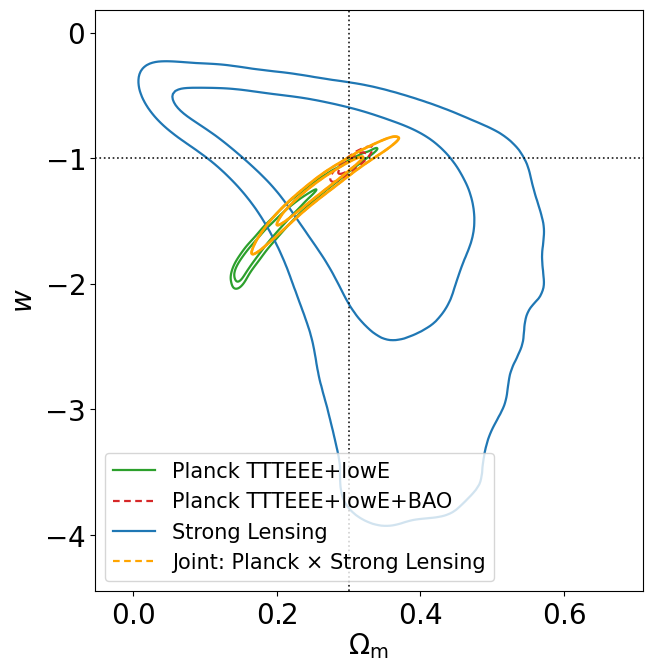

In [7]:
# Local NPZ + Planck overlays (same style as cell 0)
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ---------------- Planck roots (wCDM) ----------------
planck_base_label = "base_w"
_planck_dir_candidates = [
    "/home/geng/Codes/sgl_cosmo/jax01/data/planck_data",
    "/home/geng/Codes/sgl_cosmo/jax01/data",
]

def _resolve_planck_root(base_label, chain_name):
    tried = []
    for d in _planck_dir_candidates:
        # 1) direct root style: .../base_w/plikHM_... (rare)
        root1 = os.path.join(d, base_label, chain_name)
        tried.append(root1)
        if os.path.exists(root1 + '_1.txt') or os.path.exists(root1 + '.paramnames') or os.path.exists(root1 + '.ranges'):
            return root1

        # 2) common Planck layout in your tree:
        #    .../base_w/plikHM_.../base_w_plikHM_...
        root2 = os.path.join(d, base_label, chain_name, f"{base_label}_{chain_name}")
        tried.append(root2)
        if os.path.exists(root2 + '_1.txt') or os.path.exists(root2 + '.paramnames') or os.path.exists(root2 + '.ranges'):
            return root2

    raise FileNotFoundError(
        "Planck chain root not found. Tried:\n" + "\n".join(tried) +
        "\nPlease check your chain folder layout."
    )

root_nobao = _resolve_planck_root(planck_base_label, "plikHM_TTTEEE_lowl_lowE")
root_bao = _resolve_planck_root(planck_base_label, "plikHM_TTTEEE_lowl_lowE_BAO")

# ---------------- Local NPZ chain ----------------
npz_path = '/home/geng/Codes/sgl_cosmo/jax01/output/posterior_minimal_chunks_sgl146_wcdm_main.npz'
if not os.path.exists(npz_path):
    raise FileNotFoundError(f'Missing npz: {npz_path}')

d = np.load(npz_path)
required = ['Om', 'w']
missing = [k for k in required if k not in d]
if missing:
    raise KeyError(f'NPZ missing keys: {missing}')

local_samples = np.column_stack([d['Om'], d['w']])
local_mcs = MCSamples(
    samples=local_samples,
    names=['omegam', 'w'],
    labels=[r'\Omega_{\rm m}', 'w'],
)
local_mcs.label = 'Strong Lensing'


# ---------------- Utility functions (same method as first cell) ----------------
def ensure_omegam_and_w(samples):
    names = {p.name for p in samples.getParamNames().names}
    P = samples.getParams()

    if 'w' not in names:
        if hasattr(P, 'w0'):
            samples.addDerived(P.w0, name='w', label='w')
        else:
            raise RuntimeError('Planck chain has no w/w0')

    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2) / P.h**2, name='omegam', label=r'\Omega_{\rm m}')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2) / (P.H0/100.0)**2, name='omegam', label=r'\Omega_{\rm m}')
    try:
        samples.setLabel('omegam', r'\Omega_{\rm m}')
    except Exception:
        pass
    try:
        samples.setLabel('w', 'w')
    except Exception:
        pass
    return samples

def extract_2col_from_mcs(mcs, xname='omegam', yname='w'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde(base_mcs, ref_pts, label, bw='scott'):
    base_pts = extract_2col_from_mcs(base_mcs, 'omegam', 'w')
    w_base = base_mcs.weights if base_mcs.weights is not None else np.ones(base_pts.shape[0])

    kde = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = kde(base_pts.T)
    dens = np.clip(dens, 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(
        samples=base_pts,
        names=['omegam', 'w'],
        labels=[r'\Omega_{\rm m}', 'w'],
        weights=w_joint,
    )
    joint.label = label
    return joint

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad * w, hi + pad * w

# ---------------- Load Planck chains ----------------
planck_nobao = loadMCSamples(root_nobao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_nobao = ensure_omegam_and_w(planck_nobao)

planck_bao = loadMCSamples(root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_omegam_and_w(planck_bao)

# ---------------- Joint: Planck x local ----------------
local_pts = extract_2col_from_mcs(local_mcs, 'omegam', 'w')
joint_planck = make_joint_by_kde(
    planck_nobao,
    local_pts,
    label=r'Joint: Planck × Strong Lensing',
    bw='scott',
)

# ---------------- Plot (same overlay style) ----------------
all_samples = [planck_nobao, planck_bao, local_mcs, joint_planck]
legend_labels = [
    r'Planck TTTEEE+lowE',
    r'Planck TTTEEE+lowE+BAO',
    r'Strong Lensing',
    r'Joint: Planck × Strong Lensing',
]
colors = ['#2ca02c','#d62728', '#1f77b4',  'orange']
line_args = [
    {'ls': '-',  'lw': 1.6},
    {'ls': '--', 'lw': 1.6},
    {'ls': '-',  'lw': 1.6},
    {'ls': '--', 'lw': 1.6},
]

g = plots.get_subplot_plotter(width_inch=6.8)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

g.plot_2d(
    all_samples,
    ['omegam', 'w'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=legend_labels,
)
g.plot_2d(joint_planck, ['omegam', 'w'], filled=False, colors=[colors[3]], add_legend_proxy=False, alpha=0.3)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(all_samples, 'omegam') or (0.0, 1.05)
ylim = auto_limits_multi(all_samples, 'w') or (-2.5, -0.5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$',fontsize=20)
ax.set_ylabel(r'$w$',fontsize=20)

ax.axvline(0.3,  color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)
ax.axhline(-1.0, color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)

g.add_legend(legend_labels, legend_loc='lower left', colored_text=False,fontsize=15)

out = '/home/geng/Codes/sgl_cosmo/jax01/joint_plots/wcdm_omegam_w_SL_planck.png'
g.export(out)
print(f'Saved: {out}')


Removed no burn in
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_1.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_2.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_3.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE/base_w_plikHM_TTTEEE_lowl_lowE_4.txt
Removed no burn in
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w/plikHM_TTTEEE_lowl_lowE_BAO/base_w_plikHM_TTTEEE_lowl_l

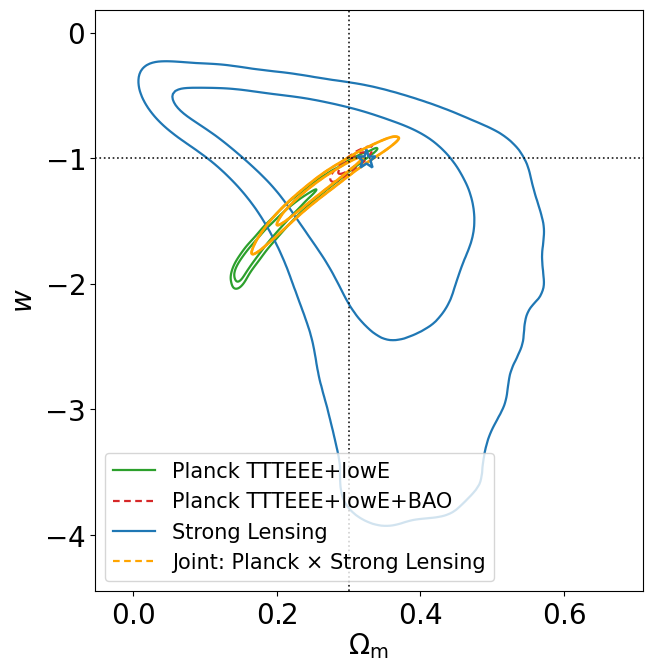

In [2]:
# Local NPZ + Planck overlays + strong-lensing peak star
import os
import numpy as np
from getdist.mcsamples import loadMCSamples, MCSamples
from getdist import plots
from scipy.stats import gaussian_kde

# ---------------- Planck roots (wCDM) ----------------
planck_base_label = "base_w"
_planck_dir_candidates = [
    "/home/geng/Codes/sgl_cosmo/jax01/data/planck_data",
    "/home/geng/Codes/sgl_cosmo/jax01/data",
]

def _resolve_planck_root(base_label, chain_name):
    tried = []
    for d in _planck_dir_candidates:
        # 1) direct root style: .../base_w/plikHM_... (rare)
        root1 = os.path.join(d, base_label, chain_name)
        tried.append(root1)
        if os.path.exists(root1 + '_1.txt') or os.path.exists(root1 + '.paramnames') or os.path.exists(root1 + '.ranges'):
            return root1

        # 2) common Planck layout in your tree:
        #    .../base_w/plikHM_.../base_w_plikHM_...
        root2 = os.path.join(d, base_label, chain_name, f"{base_label}_{chain_name}")
        tried.append(root2)
        if os.path.exists(root2 + '_1.txt') or os.path.exists(root2 + '.paramnames') or os.path.exists(root2 + '.ranges'):
            return root2

    raise FileNotFoundError(
        "Planck chain root not found. Tried:\n" + "\n".join(tried) +
        "\nPlease check your chain folder layout."
    )

root_nobao = _resolve_planck_root(planck_base_label, "plikHM_TTTEEE_lowl_lowE")
root_bao = _resolve_planck_root(planck_base_label, "plikHM_TTTEEE_lowl_lowE_BAO")

# ---------------- Local NPZ chain ----------------
npz_path = '/home/geng/Codes/sgl_cosmo/jax01/output/posterior_minimal_chunks_sgl146_wcdm_main.npz'
if not os.path.exists(npz_path):
    raise FileNotFoundError(f'Missing npz: {npz_path}')

d = np.load(npz_path)
required = ['Om', 'w']
missing = [k for k in required if k not in d]
if missing:
    raise KeyError(f'NPZ missing keys: {missing}')

local_samples = np.column_stack([d['Om'], d['w']])
local_mcs = MCSamples(
    samples=local_samples,
    names=['omegam', 'w'],
    labels=[r'\Omega_{\rm m}', 'w'],
)
local_mcs.label = 'Strong Lensing'


# ---------------- Utility functions (same method as first cell) ----------------
def ensure_omegam_and_w(samples):
    names = {p.name for p in samples.getParamNames().names}
    P = samples.getParams()

    if 'w' not in names:
        if hasattr(P, 'w0'):
            samples.addDerived(P.w0, name='w', label='w')
        else:
            raise RuntimeError('Planck chain has no w/w0')

    if 'omegam' not in names:
        if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
            if hasattr(P, 'h'):
                samples.addDerived((P.ombh2 + P.omch2) / P.h**2, name='omegam', label=r'\Omega_{\rm m}')
            elif hasattr(P, 'H0'):
                samples.addDerived((P.ombh2 + P.omch2) / (P.H0/100.0)**2, name='omegam', label=r'\Omega_{\rm m}')
    try:
        samples.setLabel('omegam', r'\Omega_{\rm m}')
    except Exception:
        pass
    try:
        samples.setLabel('w', 'w')
    except Exception:
        pass
    return samples

def extract_2col_from_mcs(mcs, xname='omegam', yname='w'):
    P = mcs.getParams()
    x = getattr(P, xname)
    y = getattr(P, yname)
    return np.vstack([x, y]).T

def make_joint_by_kde(base_mcs, ref_pts, label, bw='scott'):
    base_pts = extract_2col_from_mcs(base_mcs, 'omegam', 'w')
    w_base = base_mcs.weights if base_mcs.weights is not None else np.ones(base_pts.shape[0])

    kde = gaussian_kde(ref_pts.T, bw_method=bw)
    dens = kde(base_pts.T)
    dens = np.clip(dens, 1e-300, None)
    w_joint = w_base * dens

    joint = MCSamples(
        samples=base_pts,
        names=['omegam', 'w'],
        labels=[r'\Omega_{\rm m}', 'w'],
        weights=w_joint,
    )
    joint.label = label
    return joint

def auto_limits_multi(samples_list, name, q=(0.5, 99.5), pad=0.15):
    vals = []
    for s in samples_list:
        try:
            arr = getattr(s.getParams(), name)
            vals.append(np.percentile(arr, q))
        except Exception:
            pass
    if not vals:
        return None
    vals = np.array(vals)
    lo, hi = np.min(vals[:, 0]), np.max(vals[:, 1])
    w = hi - lo
    return lo - pad * w, hi + pad * w

# ---------------- Load Planck chains ----------------
planck_nobao = loadMCSamples(root_nobao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_nobao = ensure_omegam_and_w(planck_nobao)

planck_bao = loadMCSamples(root_bao, settings={'ignore_rows': 0.3}, no_cache=True)
planck_bao = ensure_omegam_and_w(planck_bao)

# ---------------- Joint: Planck x local ----------------
local_pts = extract_2col_from_mcs(local_mcs, 'omegam', 'w')
joint_planck = make_joint_by_kde(
    planck_nobao,
    local_pts,
    label=r'Joint: Planck × Strong Lensing',
    bw='scott',
)

# ---------------- Plot (same overlay style) ----------------
all_samples = [planck_nobao, planck_bao, local_mcs, joint_planck]
legend_labels = [
    r'Planck TTTEEE+lowE',
    r'Planck TTTEEE+lowE+BAO',
    r'Strong Lensing',
    r'Joint: Planck × Strong Lensing',
]
colors = ['#2ca02c','#d62728', '#1f77b4',  'orange']
line_args = [
    {'ls': '-',  'lw': 1.6},
    {'ls': '--', 'lw': 1.6},
    {'ls': '-',  'lw': 1.6},
    {'ls': '--', 'lw': 1.6},
]

g = plots.get_subplot_plotter(width_inch=6.8)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

g.plot_2d(
    all_samples,
    ['omegam', 'w'],
    filled=False,
    colors=colors,
    line_args=line_args,
    legend_labels=legend_labels,
)
g.plot_2d(joint_planck, ['omegam', 'w'], filled=False, colors=[colors[3]], add_legend_proxy=False, alpha=0.3)

ax = g.subplots[0, 0]
xlim = auto_limits_multi(all_samples, 'omegam') or (0.0, 1.05)
ylim = auto_limits_multi(all_samples, 'w') or (-2.5, -0.5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r'$\Omega_{\mathrm{m}}$',fontsize=20)
ax.set_ylabel(r'$w$',fontsize=20)

ax.axvline(0.3,  color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)
ax.axhline(-1.0, color='k', ls=':', lw=1.2, alpha=0.9, zorder=2)

# Strong lensing peak from the statistics cell (hollow pentagram)
ax.plot(
    0.324798, -1.007892,
    marker='*', markersize=14, linestyle='None',
    markerfacecolor='none', markeredgecolor=colors[2], markeredgewidth=1.8,
    zorder=6,
)

g.add_legend(legend_labels, legend_loc='lower left', colored_text=False,fontsize=15)

out = '/home/geng/Codes/sgl_cosmo/jax01/joint_plots/wcdm_omegam_w_SL_planck_with_peak_star.png'
g.export(out)
print(f'Saved: {out}')


In [2]:
# === (2) 一维统计量：mean/sigma、median/MAD、peak/q16/q84（含相对 peak 的不对称误差）===
import numpy as np
from scipy.stats import gaussian_kde

def _normalize_weights(w):
    if w is None: return None
    w = np.asarray(w, float)
    s = np.sum(w)
    if s <= 0 or not np.isfinite(s): return None
    return w / s

def _weighted_quantile(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.quantile(x, q)
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return np.interp(q, cdf, xs)

def _weighted_quantiles(x, qs, w=None):
    qs = np.atleast_1d(qs).astype(float)
    return np.array([_weighted_quantile(x, q, w) for q in qs])

def _weighted_median(x, w=None):
    return _weighted_quantile(x, 0.5, w)

def _weighted_mad(x, w=None, scale=1.4826):
    med = _weighted_median(x, w)
    return scale * _weighted_median(np.abs(x - med), w)

def _oned_peak(x, w=None, grids=2048):
    x = np.asarray(x, float)
    grid = np.linspace(np.min(x), np.max(x), grids)
    kde  = gaussian_kde(x, weights=w) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return grid[np.argmax(dens)]

def _weighted_mean_sigma(x, w=None):
    x = np.asarray(x, float)
    if w is None:
        return np.mean(x), np.std(x, ddof=0)
    wn = _normalize_weights(w)
    mu = np.sum(wn * x)
    sig = np.sqrt(np.sum(wn * (x - mu)**2))
    return mu, sig

def _get_param_array(mcs, name):
    P = mcs.getParams()
    return np.asarray(getattr(P, name), float)

def summarize_mcs_1dset(mcs, names=('omegam','w')):
    out = {}
    wts = None if mcs.weights is None else np.asarray(mcs.weights, float)
    for nm in names:
        arr = _get_param_array(mcs, nm)
        mean, sigma = _weighted_mean_sigma(arr, wts)
        med  = _weighted_median(arr, wts)
        mad  = _weighted_mad(arr, wts)
        pk   = _oned_peak(arr, wts)
        q16, q84 = _weighted_quantiles(arr, [0.16, 0.84], wts)
        out[nm] = dict(
            mean=mean, sigma=sigma,
            median=med, mad=mad,
            peak=pk, q16=q16, q84=q84,
            dmed_minus=med-q16, dmed_plus=q84-med
        )
    return out

def print_summary_1d(tag, summ, names=('omegam','w')):
    print(f"\n=== {tag} ===")
    for nm in names:
        s = summ[nm]
        peak_txt   = f"peak = {s['peak']:.6f} "
        median_txt = f"median = {s['median']:.6f} (q16={s['q16']:.6f}, q84={s['q84']:.6f};  Δ-={s['dmed_minus']:.6f}, Δ+={s['dmed_plus']:.6f}) (MAD={s['mad']:.6f})"
        mean_txt   = f"mean = {s['mean']:.6f}, sigma = {s['sigma']:.6f}"
        print(f"{nm:7s}: {peak_txt} | {median_txt} | {mean_txt}")

# ---- 按 5 组输出（需与上一个代码块中的对象名一致）----
stats_targets = [
    (getattr(local_mcs, "label", "Local"), local_mcs),
    (getattr(planck_nobao, "label", "Planck"), planck_nobao),
    (getattr(planck_bao, "label", "Planck+BAO"), planck_bao),
    (getattr(joint_planck, "label", "Joint"), joint_planck),
]

for tag, mcs in stats_targets:
    s = summarize_mcs_1dset(mcs, names=('omegam','w'))
    print_summary_1d(tag, s, names=('omegam','w'))



=== Strong Lensing ===
omegam : peak = 0.324798  | median = 0.327793 (q16=0.215101, q84=0.431382;  Δ-=0.112692, Δ+=0.103589) (MAD=0.105196) | mean = 0.324376, sigma = 0.111956
w      : peak = -1.007892  | median = -1.333242 (q16=-2.300223, q84=-0.767560;  Δ-=0.966982, Δ+=0.565682) (MAD=0.701976) | mean = -1.509474, sigma = 0.790541

=== None ===
omegam : peak = 0.155202  | median = 0.184396 (q16=0.153777, q84=0.243869;  Δ-=0.030619, Δ+=0.059473) (MAD=0.041114) | mean = 0.197653, sigma = 0.047638
w      : peak = -1.788563  | median = -1.631162 (q16=-1.856842, q84=-1.298890;  Δ-=0.225681, Δ+=0.332272) (MAD=0.280285) | mean = -1.584911, sigma = 0.265049

=== None ===
omegam : peak = 0.306315  | median = 0.303908 (q16=0.291676, q84=0.315791;  Δ-=0.012232, Δ+=0.011883) (MAD=0.012213) | mean = 0.303785, sigma = 0.012148
w      : peak = -1.030702  | median = -1.038892 (q16=-1.097818, q84=-0.983872;  Δ-=0.058926, Δ+=0.055020) (MAD=0.057137) | mean = -1.040797, sigma = 0.057410

=== Joint: Pla